# E-commerce Data Cleaning & Analysis Project
#### Project Overview:
##### This Porject focuses on cleaning and preparing a raw e-commerce dataset for business analysis. The main goal is to handle missing data, fix formatting issues, remove anomalies, and prepare the data for extracting key business insigts.

### Importing Required Libraries 
##### In this section, we import key Python Libraries for data manipulation (Pandas, NumPY) and data visualizaton (Matplotlib, Seaborn).

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Data Loading
##### Note : Using ISO-8859-1 encoding to handle special characters in products name. 

In [66]:
df = pd.read_csv("Ecommerce.csv", encoding= "ISO-8859-1")

In [67]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Exploratory Data Analysis (EDA)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [69]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Handling missing values
##### We handle missing data by filling null values in the Description column with 'Unknown' and assigning a placeholder '99999' for missing CustomerID records.


In [70]:
df["Description"]= df["Description"].fillna("Unknown")
df["CustomerID"]=df["CustomerID"].fillna("99999")

### Data type conversion
##### We cast the CustomerID column into an integer format to ensure proper data representation and efficient 

In [72]:
df["CustomerID"] = df["CustomerID"].astype(int)

### Parsing InvoiceDate to Datetime Object
##### We convert the InvoiceDate from a string (text) format into a proper pandas datetime object. This allows us to extract time-based features like months and hours later.

In [73]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format = 'mixed')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  541909 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   541909 non-null  int64         
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 33.1+ MB


In [75]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Filtering Ouliers & Negative Values
##### We filter the dataset to reatin only positive transactions.We exclude negative or zero values from 'Quantity' and 'UnitPrice' (which usually represent cancelled orders or bad data) to focus solely on successful sales.)


In [77]:
df2 = df[(df["Quantity"]>0) & (df["UnitPrice"] >=0)].copy()

In [78]:
df2.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,531283.000000,531283,531283.000000,531283.000000
mean,10.655299,2011-07-04 18:15:33.177910016,3.898954,36556.301841
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,1.000000,2011-03-28 11:59:00,1.250000,14388.000000
50%,3.000000,2011-07-20 12:01:00,2.080000,16271.000000
75%,10.000000,2011-10-19 12:35:00,4.130000,99999.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,99999.000000
std,156.830617,NaN,35.876279,36757.564936


In [79]:
df2["TotalAmount"]= df2["Quantity"]*df2["UnitPrice"]

In [80]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Top 5 Countries by Total Sales
#### We aggregate the total revenue generated by each country to identify our biggest markets. We first calculate the Total Sales per country and then visualize the the top 5 leaders in a bar chart.
##### *(Note: The '1e6' on the Y-axis represents 1 Million or 10 Lakhs, meaning the United Kingdom is leading with over 9 Million in sales).*

In [81]:
top_countries = df2.groupby("Country")["TotalAmount"].sum().sort_values(ascending= False).head(5)
top_countries

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Name: TotalAmount, dtype: float64

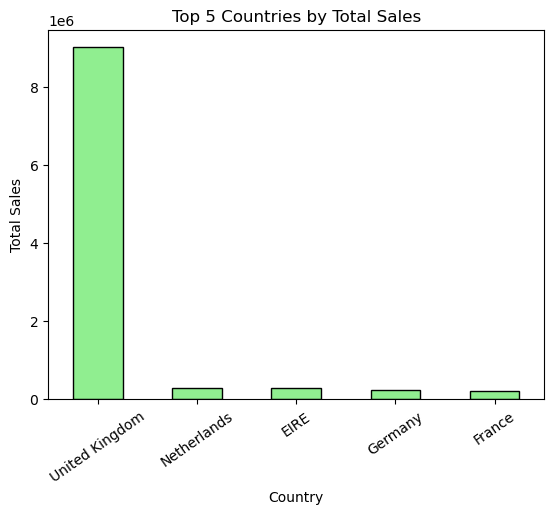

In [82]:
top_countries.plot(kind= 'bar', rot=35, color='lightgreen', edgecolor ='black')
plt.title('Top 5 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.show()

### Top 5 Best-Selling Products
#### Here we identify the most popular products based on the total quantity sold. We aggregate the total quantity per product description, sort them in descending order, and visualize the top 5 Best selling products.

In [83]:
top_products = df2.groupby("Description")["Quantity"].sum().sort_values(ascending= False).head(5)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48478
WHITE HANGING HEART T-LIGHT HOLDER    37895
Name: Quantity, dtype: int64

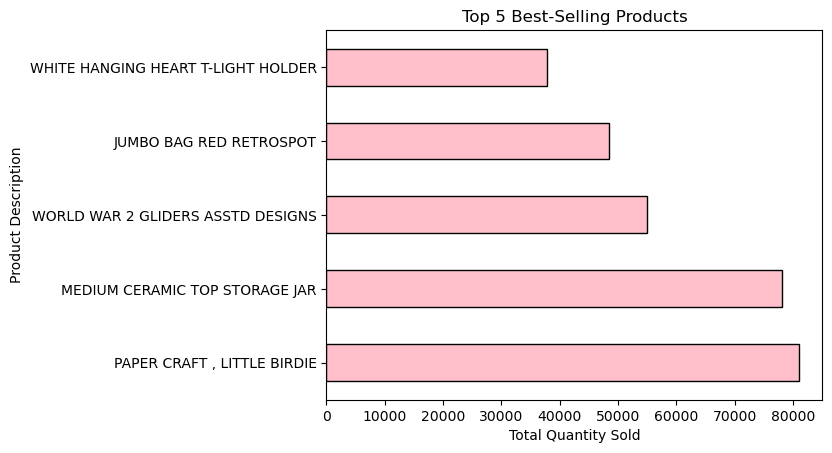

In [84]:
top_products.plot(kind = 'barh', color= 'pink',  edgecolor= 'black')
plt.title('Top 5 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.show()

In [85]:
df2["InvoiceMonth"] = df2["InvoiceDate"].dt.to_period("M")

In [86]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


### Monthly Sales Trend (Time-Series)
##### This analysis tracks the business's sales performance over time. We group the data by month to calculate total revenue, which allows us to observe consumer demand shifts and seasonal trends.

In [87]:
monthly_sales = df2.groupby("InvoiceMonth")["TotalAmount"].sum()
monthly_sales

InvoiceMonth
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: TotalAmount, dtype: float64

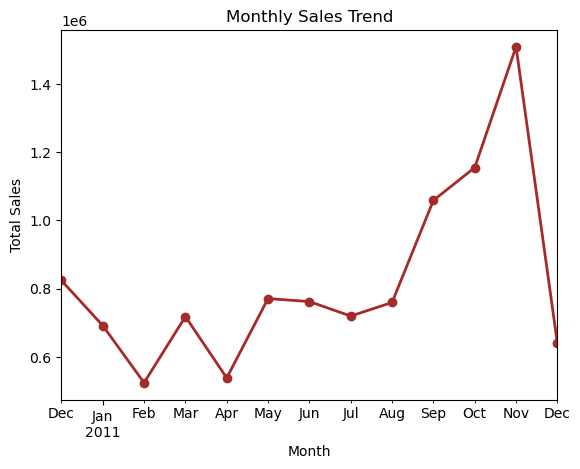

In [88]:
monthly_sales.plot(kind= 'line', marker= 'o', color= 'brown', linewidth= 2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [89]:
df2["InvoiceHour"] = df2["InvoiceDate"].dt.hour
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceMonth,InvoiceHour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,8


### Order Distribution by Hour of the Day
##### To pinpoint peak shopping traffic, we calculate the number of unique orders received during each hour of the day. This analysis helps determine the ideal timing for running marketing campaigns or flash sales.

In [90]:
hourly_orders = df2.groupby("InvoiceHour")["InvoiceNo"].nunique()
hourly_orders

InvoiceHour
6        1
7       29
8      568
9     1538
10    2431
11    2473
12    3323
13    2818
14    2555
15    2474
16    1406
17     738
18     209
19     146
20      18
Name: InvoiceNo, dtype: int64

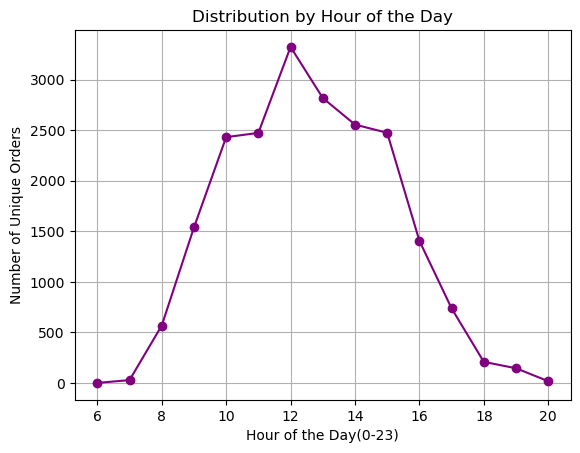

In [91]:
hourly_orders.plot(kind='line', marker='o', color='purple')
plt.title('Distribution by Hour of the Day')
plt.xlabel('Hour of the Day(0-23)')
plt.ylabel('Number of Unique Orders')
plt.grid(True)
plt.show()